In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import barnaba as bb
import os

In [2]:
BME_DIR = "bme_reweight"
tag = "hcp_rdc_3j_theta=16"
weights = np.load(f"{BME_DIR}/crossvals/crossval_{tag}/weights_results.npy")[0]
weights = weights.T
sub = "random_noReplace" #indicator which subensemble should be used
rdc_calc = np.loadtxt(f'calc_data/calc_rdc_loop_bme.dat')[:,1:]
w0 = np.full(rdc_calc.shape[0], 1/rdc_calc.shape[0]) # sample weights

# Calculate RMSE and $\chi^2$ comparing Experimental and (Reweighted) Calculated Data 

## Load Experimental, Calculated and Bundle Data

In [3]:

# Bundle identifiers:
bundles = []
for i in range(5):
    bundles.append(f"cluster_{i}")
print(bundles)

# labels
hcch_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcn_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
hcp_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat", delim_whitespace=True, usecols=[0]).index)
noe_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_noe_loop_bme.dat", delim_whitespace=True, usecols=[0])['#'])
j3_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_j3_bme.dat", delim_whitespace=True, usecols=[0]).index)
rdc_lbl  = list(pd.read_csv(f"{BME_DIR}/exp_rdc_bme.dat", delim_whitespace=True, usecols=[0]).index)


# Experimental
rdc_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_bme.dat",usecols=[1,2])
hcch_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcch_loop_bme.dat",usecols=[1,2])
hcn_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcn_loop_bme.dat",usecols=[1,2])
hcp_exp = np.loadtxt(f"{BME_DIR}/exp_ccr_hcp_loop_bme.dat",usecols=[1,2])
noe_exp = np.loadtxt(f"{BME_DIR}/exp_noe_loop_bme.dat",usecols=[1,2])
j3_exp = np.loadtxt(f"{BME_DIR}/exp_j3_bme.dat",usecols=[1,2])

## Experimental for PDB structure 1ZIH, which has different stem needs to be fitted with only loop rdcs
rdc_1ZIH_exp = np.loadtxt(f"{BME_DIR}/exp_rdc_loop_bme.dat",usecols=[1,2])

# Calculated
rdc_calc = np.loadtxt(f"{BME_DIR}/calc_rdc_bme.dat")[:,1:]
hcch_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcch_loop_bme.dat")[:,1:]
hcn_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcn_loop_bme.dat")[:,1:]
hcp_calc = np.loadtxt(f"{BME_DIR}/calc_ccr_hcp_loop_bme.dat")[:,1:]
noe_calc = np.loadtxt(f"{BME_DIR}/calc_noe_loop_bme.dat")[:,1:]
j3_calc = np.loadtxt(f"{BME_DIR}/calc_j3_bme.dat")[:,1:]

# Bundles
j3_bundles = {}
noe_bundles = {}
hcch_bundles = {}
hcn_bundles = {}
hcp_bundles = {}
rdc_bundles = {}
L_bundles = {}

# NMR bundle directory:
bundles_dir = 'qt_clustering_100/hcp_rdc_3j_theta=16/frames_random_noReplace_cutoff_0_9'

for b in bundles:
    j3_bundles[b]   = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_j3_loop_bme.dat')[:,1:]
    rdc_bundles[b]  = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_rdc_all_bme.dat')[:,1:]
    hcch_bundles[b] = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_ccr_calc_HCCH_loop_bme.dat')[:,1:]
    hcn_bundles[b]  = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_ccr_calc_HCN_loop_bme.dat')[:,1:]
    hcp_bundles[b]  = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_ccr_calc_HCP_loop_bme.dat')[:,1:]
    noe_bundles[b]  = np.loadtxt(f'{bundles_dir}/nmrbundle_{b}_dists_loop.dat')[:,1:]
    L_bundles[b]    = np.load(f'{bundles_dir}/nmrbundle_{b}_rdc_all_bme_L.npy') 

# L_calc
L_calc = np.sum(rdc_exp[:,0]*np.average(rdc_calc, axis=0))/np.sum(np.average(rdc_calc, axis=0)*np.average(rdc_calc, axis=0))

# Reweighted weights
w_rew = weights

['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4']


## Use RMSE Script to calc all RMSE

In [4]:
%load_ext autoreload
%autoreload 2
import os
import sys
module_path = os.path.abspath(os.path.join('lib')) # or the path to your source code
sys.path.insert(0, module_path)

In [5]:
import lib.rmse as rmse
from importlib import reload
reload(rmse)

<module 'lib.rmse' from 'z:\\14_MD_stuff\\20250709_GAAG_analysis_V4\\lib\\rmse.py'>

In [6]:
frames = np.load(f"qt_clustering_100/{tag}/subsampled_frames_{sub}.npy")
w_new = weights

rmse_md = {}
# calc rmse for MD simulation compared to experimanetal data
rmse_md['MD'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w0), 
                          rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w0),
                          rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w0), 
                          rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w0, noe=True)])

# calc rmse for reweighted MD simulation compared to experimental data
rmse_md['MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w_rew[:].T), 
                              rmse.calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w_rew[:]), 
                              rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w_rew[:]),
                              rmse.calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w_rew[:], noe=True)])

w0_100 = np.array([1/100]*100)
rmse_md['Bundle MD+Exp'] = np.array([rmse.calc_RMSE_ensemble(rdc_exp, rdc_calc[frames,:]*L_calc, w0_100), 
                                     rmse.calc_RMSE_ensemble(j3_exp, j3_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(hcch_exp, hcch_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcn_exp, hcn_calc[frames,:], w0_100),
                                     rmse.calc_RMSE_ensemble(hcp_exp, hcp_calc[frames,:], w0_100), 
                                     rmse.calc_RMSE_ensemble(noe_exp, noe_calc[frames,:], w0_100, noe=True)])

In [7]:
rmse_bundles = {}
for b in bundles:
    print(b)
    if b == "1ZIH":
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_1ZIH_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T), 
            rmse.calc_RMSE_bundle(j3_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcn_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcp_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(noe_exp, noe_bundles[b][:,:])
        ])        
    else:
        rmse_bundles[b] = np.array([
            rmse.calc_RMSE_bundle(rdc_exp, (rdc_bundles[b][:,:].T*L_bundles[b]).T),
            rmse.calc_RMSE_bundle(j3_exp, j3_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(hcch_exp, hcch_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcn_exp, hcn_bundles[b][:,:]),
            rmse.calc_RMSE_bundle(hcp_exp, hcp_bundles[b][:,:]), 
            rmse.calc_RMSE_bundle(noe_exp, noe_bundles[b][:,:])
        ])

cluster_0
cluster_1
cluster_2
cluster_3
cluster_4


In [8]:
rmse_err = np.array([
    np.sqrt(np.average(rdc_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(j3_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcch_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcn_exp[:,1]**2, axis=-1)),
    np.sqrt(np.average(hcp_exp[:,1]**2, axis=-1)),
    np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6),
])

In [9]:
np.power(np.average(np.power(noe_exp[:,1], -6), axis=0), -1.0 / 6)

0.7059391400463275

# Plot RMSE

['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

RDC [Hz]
MD: 5.65 +/- 1.5
MD+Exp: 3.12 +/- 1.5
Bundle
MD+Exp: 3.56 +/- 1.5
cluster_0: 5.39
cluster_1: 5.76
cluster_2: 5.84
cluster_3: 7.15
cluster_4: 6.16

3J [Hz]
MD: 3.00 +/- 1.32
MD+Exp: 1.93 +/- 1.32
Bundle
MD+Exp: 2.01 +/- 1.32
cluster_0: 3.40
cluster_1: 4.15
cluster_2: 3.62
cluster_3: 4.17
cluster_4: 3.77

$\Gamma$-HCCH [Hz]
MD: 11.32 +/- 2.04
MD+Exp: 5.98 +/- 2.04
Bundle
MD+Exp: 6.58 +/- 2.04
cluster_0: 11.25
cluster_1: 12.61
cluster_2: 11.51
cluster_3: 11.75
cluster_4: 11.86

$\Gamma$-HCN [Hz]
MD: 3.70 +/- 1.14
MD+Exp: 3.10 +/- 1.14
Bundle
MD+Exp: 3.35 +/- 1.14
cluster_0: 5.03
cluster_1: 5.98
cluster_2: 5.84
cluster_3: 11.82
cluster_4: 6.01

$\Gamma$-HCP [Hz]
MD: 9.16 +/- 1.5
MD+Exp: 4.06 +/- 1.5
Bundle
MD+Exp: 4.54 +/- 1.5
cluster_0: 14.53
cluster_1: 16.15
cluster_2: 15.09
cluster_3: 19.85
cluster_4: 17.86

NOE [$\AA$]
MD: 1.29 +/- 0.71
MD+Exp: 1.19 +/- 0.71
Bundle
MD+Exp: 1.17 +/- 0.71
cluster_0: 1.89
cluster_

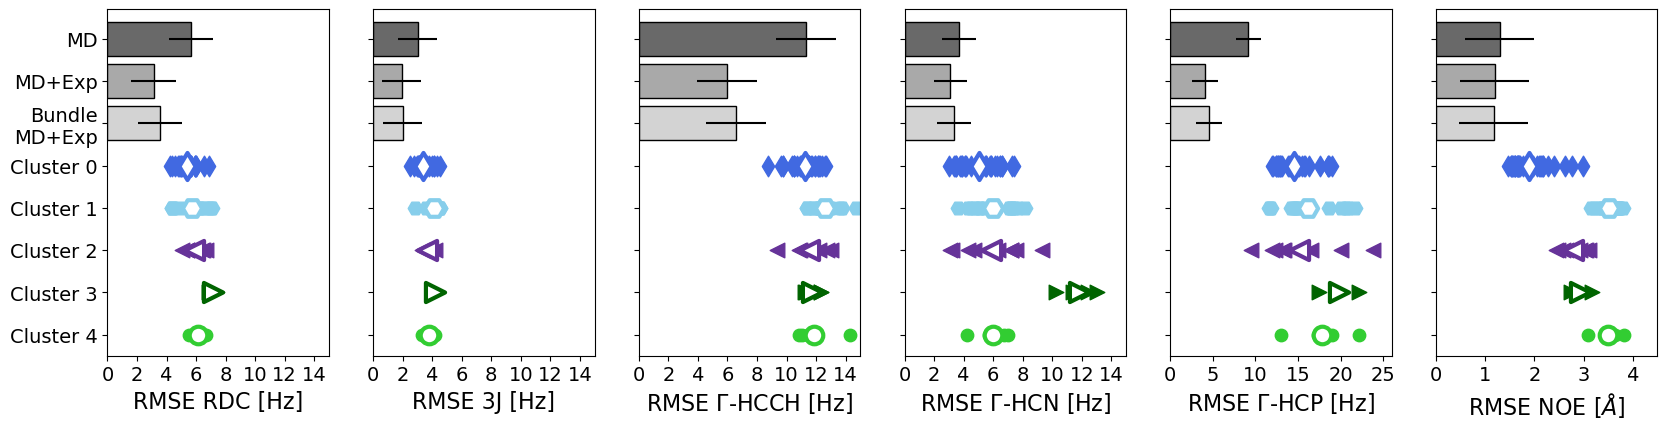

In [10]:
greys = ['dimgrey', 'darkgrey', 'lightgrey']
lbl = ['RDC [Hz]', '3J [Hz]', r'$\Gamma$-HCCH [Hz]', r'$\Gamma$-HCN [Hz]',r'$\Gamma$-HCP [Hz]', r'NOE [$\AA$]']
b_lbl = []
for bundle in range(len(bundles)):
    b_lbl.append(f"Cluster {bundle}")
print(b_lbl)
x_lbl = ['MD', 'MD+Exp', 'Bundle\nMD+Exp'] + b_lbl
lbl_dict_ = {
    # 3J:
    "C4Pb": r"$\rm ^3J(C4'_{i}\!,\!P_{i})$",
    "C4Pe": r"$\rm ^3J(C4'_{i}\!,\!P_{i\!+\!1})$",
    "1H5P": r"$\rm ^3J(H5'\!,\!P_{i})$",
    "2H5P": r"$\rm ^3J(H5''\!,\!P_{i})$",
    "1H5H4": r"$\rm ^3J(H4'\!,\!H5')$",
    "2H5H4": r"$\rm ^3J(H4'\!,\!H5'')$",
    "H1H2": r"$\rm ^3J(H1'\!,\!H2')$",
    "H2H3": r"$\rm ^3J(H2'\!,\!H3')$",
    "H3H4": r"$\rm ^3J(H3'\!,\!H4')$",
    "H3P": r"$\rm ^3J(H3'\!,\!P_{i\!+\!1})$",
    
    # CCR:
    "C1-C2": r"$\rm \Gamma^{DD\!,\!DD}_{(C1'H1'\!,\!C2'H2')}$",
    "C3-C4": r"$\rm \Gamma^{DD\!,\!DD}_{(C3'H3'\!,\!C4'H4')}$",
    "C4p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i})}$",
    "C3p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C3'_iH3_i\!,\!P_{i\!+\!1})}$",
    "C4p-P-plus": r"$\rm \Gamma^{DD\!,\!CSA}_{(C4'_iH4_i\!,\!P_{i\!+\!1})}$",
    "C5p-P": r"$\rm \Gamma^{DD\!,\!CSA}_{(C5'_iH5_i\!,\!P_{i})}$",
            }

cc = ['royalblue', 'skyblue', 'rebeccapurple', 'darkgreen', 'limegreen', 'teal'] #'#56B4E9', '#009E74', '#D55C00', '#F0E442', '#826aed', '#ff90b3', '#f7d9a7'
markers = ['d', 'H', '<', '>', 'o', 'v','D']
msizes = [110, 110, 110, 110, 80, 110, 80] # markersizes

fig, axes= plt.subplots(1,len(lbl),figsize=[20,4.5], sharey=True)


for i in range(len(lbl)):
    print(f'\n{lbl[i]:}')
    plt.subplot(1,len(lbl),i+1)
    for j,k in enumerate(rmse_md.keys()):
        if i == len(lbl):
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=np.array(rmse_md[k][i],rmse_err[i]))
        else:
            plt.barh(x_lbl[j], rmse_md[k][i], edgecolor='k', color=greys[j], height=0.8, xerr=rmse_err[i])
        print(f'{x_lbl[j]}: {rmse_md[k][i]:.2f} +/- {round(rmse_err[i],2)}')

    for j,k in enumerate(rmse_bundles.keys()):
        plt.scatter(rmse_bundles[k][i,:], [k for j in range(rmse_bundles[k].shape[-1])], marker=markers[j], color=cc[j], s=msizes[j])#, alpha=0.7)
        plt.scatter(np.average(rmse_bundles[k][i,:]), k, marker=markers[j], edgecolor=cc[j], color='w', s=msizes[j]+80, zorder=10, linewidths=3)
        print(f'{k}: {np.average(rmse_bundles[k][i,:]):.2f}')
    
    plt.yticks(range(len(x_lbl)), x_lbl, rotation=0, fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(f'RMSE {lbl[i]}', fontsize=16)     
    plt.ylim(-0.7,len(x_lbl)-0.5) 
    plt.gca().invert_yaxis()
    for b in range(0,(len(lbl)-1)):
        if b == 4:
            x_range = 25
            plt.sca(axes[b])
            plt.xticks(range(0,x_range+1,5))
            plt.xlim(0,len(range(x_range+1))) 
        else:
            x_range = 14
            plt.sca(axes[b])
            plt.xticks(range(0,x_range+1,2))
            plt.xlim(0,len(range(x_range+1))) 
        
    plt.sca(axes[(len(lbl)-1)])
    #plt.xticks([0.00, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00])
    plt.xticks([0, 1, 2, 3, 4])
    plt.xlim(0,4.5)
#plt.tight_layout(pad=6)
# plt.savefig(f'plots/rmse_comp_all_horiz.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.savefig(f'plots/clusters_rmse_comp_all_horiz.pdf', facecolor='white', bbox_inches='tight')
plt.savefig(f'plots/clusters_rmse_comp_all_horiz.png', facecolor='white', bbox_inches='tight')
plt.show()
